In [1]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_parquet('data/ml_features_with_weather.parquet')

In [3]:
df.head()

,hour,PULocationID,demand,hour_of_day,cluster,lag_1,lag_24,lag_168,day_of_week,day_of_month,...,is_holiday,temp,rhum,prcp,snow,wspd,is_rain,is_snow,is_cold,is_hot
0,2023-01-08 00:00:00,1,0.0,0,0,0.0,0.0,0.0,6,8,...,0,1.5,73,0.0,0.0,11.6,0,0,0,0
1,2023-01-08 01:00:00,1,0.0,1,0,0.0,0.0,0.0,6,8,...,0,1.1,71,0.0,0.0,11.2,0,0,0,0
2,2023-01-08 02:00:00,1,0.0,2,0,0.0,0.0,0.0,6,8,...,0,0.8,70,0.0,0.0,13.7,0,0,0,0
3,2023-01-08 03:00:00,1,0.0,3,0,0.0,0.0,0.0,6,8,...,0,0.2,72,0.0,0.0,13.6,0,0,0,0
4,2023-01-08 04:00:00,1,0.0,4,0,0.0,0.0,0.0,6,8,...,0,-0.4,72,0.0,0.0,11.3,0,0,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2259696 entries, 0 to 2259695
Data columns (total 27 columns):
 #   Column        Dtype         
---  ------        -----         
 0   hour          datetime64[ns]
 1   PULocationID  int64         
 2   demand        float64       
 3   hour_of_day   int32         
 4   cluster       int64         
 5   lag_1         float64       
 6   lag_24        float64       
 7   lag_168       float64       
 8   day_of_week   int32         
 9   day_of_month  int32         
 10  month         int32         
 11  is_weekend    int64         
 12  is_peak_hour  int64         
 13  hour_sin      float64       
 14  hour_cos      float64       
 15  dow_sin       float64       
 16  dow_cos       float64       
 17  is_holiday    int64         
 18  temp          float64       
 19  rhum          int64         
 20  prcp          float64       
 21  snow          float64       
 22  wspd          float64       
 23  is_rain       int64         
 24

In [5]:
train_end = "2023-10-31 23:00:00"
val_end   = "2023-11-30 23:00:00"


In [6]:
train_df = df[df["hour"] <= train_end]
val_df   = df[(df["hour"] > train_end) & (df["hour"] <= val_end)]
test_df  = df[df["hour"] > val_end]


In [7]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)


(1874664, 27)
(189360, 27)
(195672, 27)


In [8]:
target = "demand"
drop_cols = ["hour"]  # datetime should NOT go into model
X_train = train_df.drop(columns=[target] + drop_cols)
y_train = train_df[target]

X_val = val_df.drop(columns=[target] + drop_cols)
y_val = val_df[target]

X_test = test_df.drop(columns=[target] + drop_cols)
y_test = test_df[target]


In [9]:
y_val_pred_baseline = X_val["lag_24"]
y_test_pred_baseline = X_test["lag_24"]


In [10]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


In [11]:
val_rmse_baseline = rmse(y_val, y_val_pred_baseline)
test_rmse_baseline = rmse(y_test, y_test_pred_baseline)

val_mape_baseline = mean_absolute_percentage_error(y_val, y_val_pred_baseline)
test_mape_baseline = mean_absolute_percentage_error(y_test, y_test_pred_baseline)

print("BASELINE RESULTS")
print(f"Val RMSE  : {val_rmse_baseline:.4f}")
print(f"Test RMSE : {test_rmse_baseline:.4f}")
print(f"Val MAPE  : {val_mape_baseline:.4f}")
print(f"Test MAPE : {test_mape_baseline:.4f}")


BASELINE RESULTS
Val RMSE  : 0.4903
Test RMSE : 0.5102
Val MAPE  : 342003796136261.4375
Test MAPE : 369099714691117.1250


In [12]:
import xgboost as xgb
import numpy as np
from xgboost.callback import EarlyStopping


In [13]:
import xgboost as xgb

model = xgb.XGBRegressor(
    n_estimators=300,          # reduce to avoid overfitting
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)




In [14]:
model.fit(
    X_train,
    y_train,
    verbose=True
)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [15]:
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

val_rmse = rmse(y_val, y_val_pred)
test_rmse = rmse(y_test, y_test_pred)

print(f"Baseline Test RMSE : {test_rmse_baseline:.4f}")
print(f"XGBoost Val RMSE   : {val_rmse:.4f}")
print(f"XGBoost Test RMSE  : {test_rmse:.4f}")


Baseline Test RMSE : 0.5102
XGBoost Val RMSE   : 0.3290
XGBoost Test RMSE  : 0.3462


In [16]:
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_squared_error


In [17]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


In [18]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_val, label=y_val, reference=lgb_train)


In [19]:
params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 64,
    "max_depth": -1,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbosity": -1,
    "seed": 42
}


In [20]:
lgb_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
    valid_names=["val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(50)
    ]
)


Training until validation scores don't improve for 50 rounds
[50]	val's rmse: 0.364056
[100]	val's rmse: 0.339459
[150]	val's rmse: 0.336763
[200]	val's rmse: 0.334944
[250]	val's rmse: 0.333563
[300]	val's rmse: 0.332362
[350]	val's rmse: 0.331486
[400]	val's rmse: 0.330714
[450]	val's rmse: 0.330082
[500]	val's rmse: 0.329312
[550]	val's rmse: 0.328757
[600]	val's rmse: 0.328311
[650]	val's rmse: 0.327894
[700]	val's rmse: 0.327395
[750]	val's rmse: 0.327082
[800]	val's rmse: 0.326847
[850]	val's rmse: 0.32665
[900]	val's rmse: 0.326475
[950]	val's rmse: 0.326066
[1000]	val's rmse: 0.325877
Did not meet early stopping. Best iteration is:
[1000]	val's rmse: 0.325877


In [21]:
y_test_pred_lgb = lgb_model.predict(
    X_test, 
    num_iteration=lgb_model.best_iteration
)

lgb_test_rmse = rmse(y_test, y_test_pred_lgb)

print(f"Baseline Test RMSE : {test_rmse_baseline:.4f}")
print(f"XGBoost Test RMSE  : {test_rmse:.4f}")
print(f"LightGBM Test RMSE : {lgb_test_rmse:.4f}")


Baseline Test RMSE : 0.5102
XGBoost Test RMSE  : 0.3462
LightGBM Test RMSE : 0.3434


In [22]:
import numpy as np

y_test_pred_raw = np.expm1(y_test_pred)
y_test_true_raw = np.expm1(y_test)


In [23]:
from sklearn.metrics import mean_squared_error

rmse_raw = np.sqrt(
    mean_squared_error(y_test_true_raw, y_test_pred_raw)
)

rmse_raw


np.float64(10.415639413924294)

In [24]:
y_baseline_raw = np.expm1(y_test_pred_baseline)

rmse_baseline_raw = np.sqrt(
    mean_squared_error(y_test_true_raw, y_baseline_raw)
)

print(f"Baseline RMSE (raw) : {rmse_baseline_raw:.2f}")
print(f"Model RMSE (raw)    : {rmse_raw:.2f}")


Baseline RMSE (raw) : 18.66
Model RMSE (raw)    : 10.42


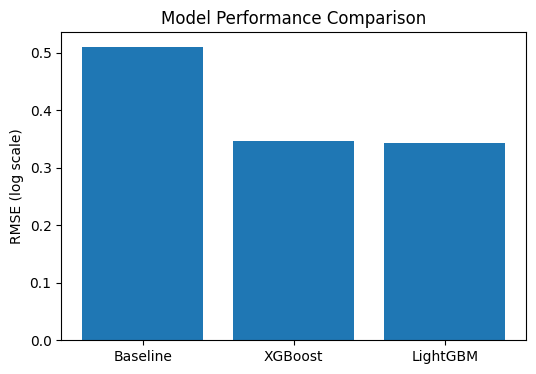

In [25]:
import matplotlib.pyplot as plt

models = ["Baseline", "XGBoost", "LightGBM"]
rmse_values = [
    test_rmse_baseline,
    test_rmse,
    lgb_test_rmse
]

plt.figure(figsize=(6,4))
plt.bar(models, rmse_values)
plt.ylabel("RMSE (log scale)")
plt.title("Model Performance Comparison")
plt.show()


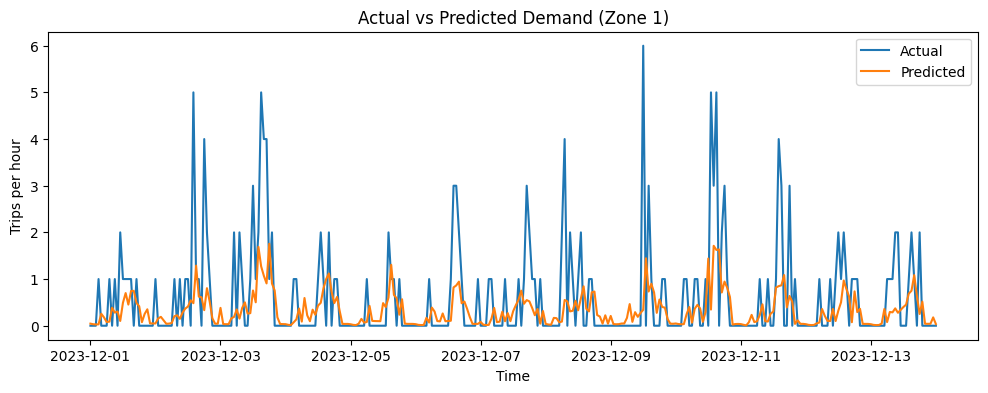

In [26]:
import numpy as np

# Pick one busy zone
zone_id = df["PULocationID"].value_counts().idxmax()

zone_df = df[
    (df["PULocationID"] == zone_id) &
    (df["hour"] >= "2023-12-01") &
    (df["hour"] <= "2023-12-14")
].copy()

zone_df = zone_df.sort_values("hour")

# Predict for this zone
X_zone = zone_df.drop(columns=["demand", "hour"])
zone_df["predicted"] = lgb_model.predict(
    X_zone, 
    num_iteration=lgb_model.best_iteration
)

# Convert back to raw scale
zone_df["actual_raw"] = np.expm1(zone_df["demand"])
zone_df["predicted_raw"] = np.expm1(zone_df["predicted"])

plt.figure(figsize=(12,4))
plt.plot(zone_df["hour"], zone_df["actual_raw"], label="Actual")
plt.plot(zone_df["hour"], zone_df["predicted_raw"], label="Predicted")
plt.legend()
plt.title(f"Actual vs Predicted Demand (Zone {zone_id})")
plt.ylabel("Trips per hour")
plt.xlabel("Time")
plt.show()


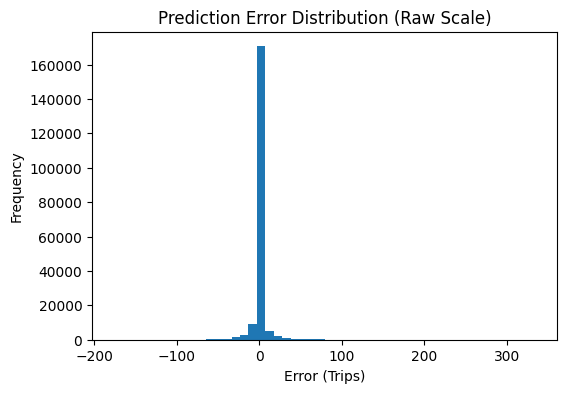

In [27]:
# Convert to raw scale
y_test_raw = np.expm1(y_test)
y_test_pred_raw = np.expm1(y_test_pred_lgb)

errors = y_test_raw - y_test_pred_raw

plt.figure(figsize=(6,4))
plt.hist(errors, bins=50)
plt.title("Prediction Error Distribution (Raw Scale)")
plt.xlabel("Error (Trips)")
plt.ylabel("Frequency")
plt.show()


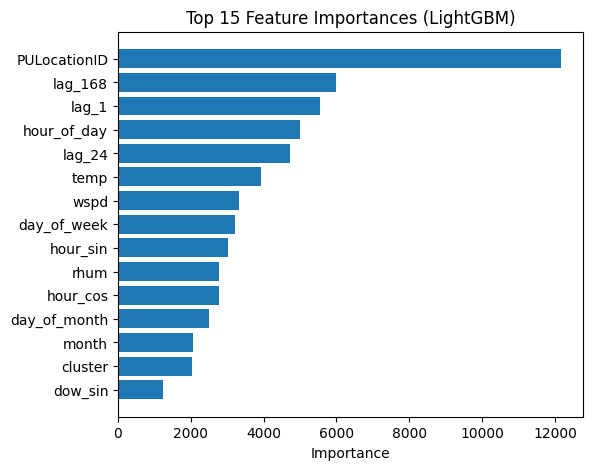

In [28]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_model.feature_importance()
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(6,5))
plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1]
)
plt.title("Top 15 Feature Importances (LightGBM)")
plt.xlabel("Importance")
plt.show()


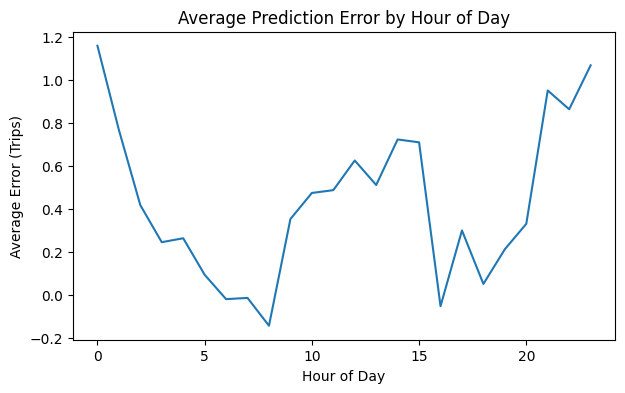

In [29]:
test_df_plot = X_test.copy()
test_df_plot["error"] = y_test_raw - y_test_pred_raw
test_df_plot["hour_of_day"] = df.loc[X_test.index, "hour"].dt.hour

hourly_error = test_df_plot.groupby("hour_of_day")["error"].mean()

plt.figure(figsize=(7,4))
plt.plot(hourly_error.index, hourly_error.values)
plt.title("Average Prediction Error by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Error (Trips)")
plt.show()


In [ ]:
y_baseline_raw = np.expm1(y_test_pred_baseline)

rmse_baseline_raw = np.sqrt(
    mean_squared_error(y_test_true_raw, y_baseline_raw)
)

print(f"Baseline RMSE (raw) : {rmse_baseline_raw:.2f}")
print(f"Model RMSE (raw)    : {rmse_raw:.2f}")


Baseline RMSE (raw) : 18.66
Model RMSE (raw)    : 10.42
